# Case Study 2

**Agenda**

* Case Study: Credit Card Fraud Detection
  * Objective
  * Introduction to the Dataset
  * Data Loading and Exploration
  * Data Preprocessing

* Class Imbalance Handling Techniques
  * Random Under Sampling
  * Random Over Sampling
  * SMOTE
  * TOMEK Links
  * SMOTE-Links
  * Conclusion

* Model Training and Evaluation with Logistics Regression
  * Defining Function
  * Evaluate Data Models
* Defining a Function to Train and Evaluate KNN
  * Defining Function
  * Evaluate Data Models
* Overview of Results

## Case Study: Credit Card Fraud Detection

### Objective

* The objective of this case study is to detect fraudulent transactions in credit card payments using machine learning algorithms, specifically Logistic Regression and K-Nearest Neighbors (KNN). We will address the class imbalance problem inherent in this dataset and implement techniques to enhance model performance.

### Introduction to the Dataset



   * V1, V2, ... V28: These are the principal components obtained through PCA (Principal Component Analysis), which anonymize the data for privacy.
   * Time: The time elapsed since the first transaction in seconds.
   * Amount: The transaction amount.
   * Class: The target variable (0 for legitimate transactions and 1 for fraudulent transactions).

### Data Loading and Exploration

#### Load the Dataset

We first load the dataset and inspect its structure and class distribution.

[Download Dataset From Here](https://drive.google.com/file/d/15tMLyQpIOeCYrPyc2qyUI3FKhveF-Tgz/view?usp=sharing)

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/creditcard.csv')  # Adjust the path as necessary
print(df.head())
print(df['Class'].value_counts())


   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

#### Exploratory Data Analysis (EDA)

* EDA helps in understanding the dataset, detecting patterns, and identifying anomalies.

   * Class Distribution: Visualize the distribution of classes.

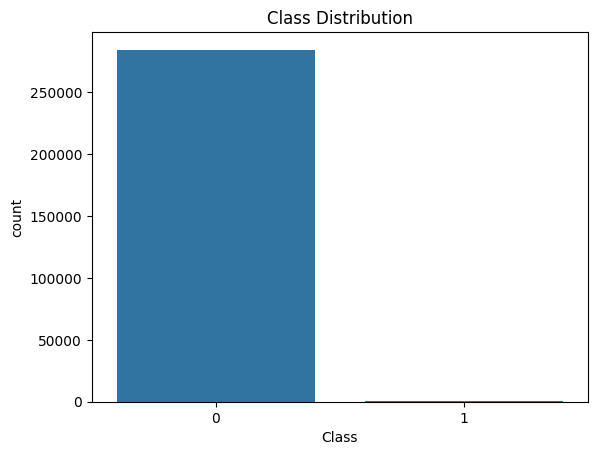

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Class', data=df)
plt.title('Class Distribution')
plt.show()


* Feature Analysis: Analyze features to understand their significance. For example, plot the transaction amounts.

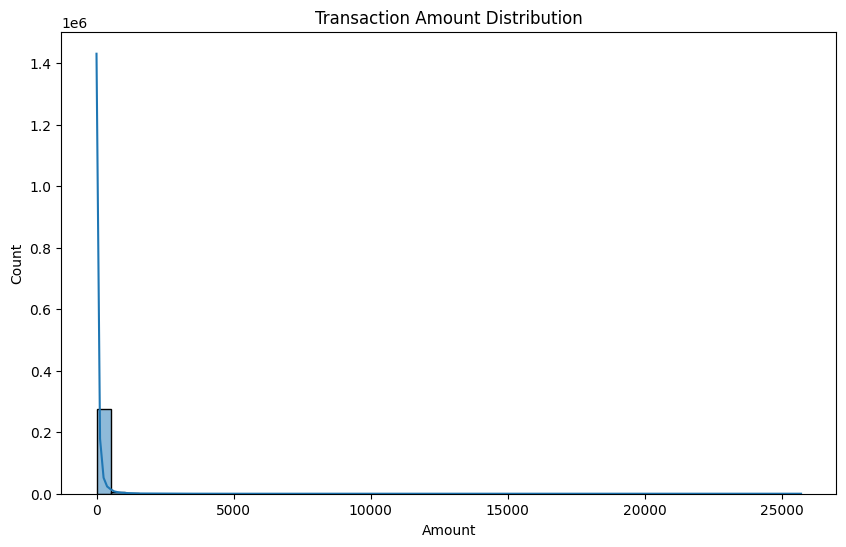

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title('Transaction Amount Distribution')
plt.show()


### Data Preprocessing

* Feature Scaling
   * Since KNN is sensitive to the scale of data, we will standardize our features.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Split features and target variable
X = df.drop('Class', axis=1)
y = df['Class']

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


#### Train-Test Split

We split the dataset into training and testing sets to evaluate the model’s performance on unseen data.

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)


## Class Imbalance Handling Techniques

###  Random Under Sampling

This technique involves randomly removing samples from the majority class.

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

# Apply Random Under Sampling
under_sampler = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = under_sampler.fit_resample(X_train, y_train)

# Count the class distribution after under sampling
print("Class distribution after Random Under Sampling:", y_train_under.value_counts())


Class distribution after Random Under Sampling: Class
0    394
1    394
Name: count, dtype: int64


### Random Over Sampling

This technique involves randomly duplicating samples from the minority class.

In [ ]:
from imblearn.over_sampling import RandomOverSampler

# Apply Random Over Sampling
over_sampler = RandomOverSampler(random_state=42)
X_train_over, y_train_over = over_sampler.fit_resample(X_train, y_train)

# Count the class distribution after over sampling
print("Class distribution after Random Over Sampling:", y_train_over.value_counts())


Class distribution after Random Over Sampling: Class
0    227451
1    227451
Name: count, dtype: int64


### SMOTE (Synthetic Minority Over-sampling Technique)

SMOTE generates synthetic samples for the minority class.



In [ ]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to balance the training dataset
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print(f'Original dataset shape {y_train.value_counts()}')
print(f'Resampled dataset shape {y_resampled.value_counts()}')

Original dataset shape Class
0    227451
1       394
Name: count, dtype: int64
Resampled dataset shape Class
0    227451
1    227451
Name: count, dtype: int64


### Tomek Links

Tomek Links removes ambiguous examples from the majority class that are close to the minority class.

In [ ]:
from imblearn.under_sampling import TomekLinks

# Apply Tomek Links
tomek = TomekLinks()
X_train_tomek, y_train_tomek = tomek.fit_resample(X_train, y_train)

# Count the class distribution after Tomek Links
print("Class distribution after Tomek Links:", y_train_tomek.value_counts())


Class distribution after Tomek Links: Class
0    227434
1       394
Name: count, dtype: int64


### SMOTE-Tomek

This technique combines SMOTE and Tomek Links for better results.

In [ ]:
from imblearn.combine import SMOTETomek

# Apply SMOTE-Tomek
smote_tomek = SMOTETomek(random_state=42)
X_train_smote_tomek, y_train_smote_tomek = smote_tomek.fit_resample(X_train, y_train)

# Count the class distribution after SMOTE-Tomek
print("Class distribution after SMOTE-Tomek:", y_train_smote_tomek.value_counts())


Class distribution after SMOTE-Tomek: Class
0    227451
1    227451
Name: count, dtype: int64


### Conclusion of Imbalance Handling Techniques

* Random Under Sampling: This method is simple but can lead to loss of important data. It generally results in lower recall but can improve precision.

* Random Over Sampling: This technique improves recall significantly by duplicating minority instances, but can lead to overfitting.

* SMOTE: SMOTE effectively increases the number of minority samples and generally provides good results in terms of recall and F1 score.

* Tomek Links: This method helps in cleaning the dataset by removing ambiguous samples, leading to clearer decision boundaries.

* SMOTE-Tomek: This combination of techniques generally yields the best performance, leveraging the strengths of both SMOTE and Tomek Links.

###  Recommendations

* For models requiring high precision, Random Under Sampling or Tomek Links can be considered.
* If high recall is a priority, SMOTE and SMOTE-Tomek are recommended.
* The best approach often depends on the specific context of the business problem and acceptable trade-offs between precision and recall.

## Model Training and Evaluation with Logistics Regression

We will train a Logistic Regression model on each of the balanced datasets and evaluate their performance.

 ### Defining a Function to Train and Evaluate Models

In [ ]:
def evaluate_model(X_train, y_train, X_test, y_test):
    # Train Logistic Regression
    log_reg = LogisticRegression()
    log_reg.fit(X_train, y_train)

    # Predict on the test set
    y_pred = log_reg.predict(X_test)

    # Calculate evaluation metrics
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)

    return precision, recall, f1, roc_auc


### Evaluate Models on Each Resampled Dataset

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(X_train, y_train, X_test, y_test):
    # Train Logistic Regression
    log_reg = LogisticRegression()
    log_reg.fit(X_train, y_train)

    # Predict on the test set
    y_pred = log_reg.predict(X_test)

    # Calculate evaluation metrics
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)

    return precision, recall, f1, roc_auc # Added return statement to return the calculated metrics

# Evaluate on Random Under Sampling
precision_under, recall_under, f1_under, roc_auc_under = evaluate_model(X_train_under, y_train_under, X_test, y_test)

# Evaluate on Random Over Sampling
precision_over, recall_over, f1_over, roc_auc_over = evaluate_model(X_train_over, y_train_over, X_test, y_test)

# Evaluate on SMOTE
precision_smote, recall_smote, f1_smote, roc_auc_smote = evaluate_model(X_resampled, y_resampled, X_test, y_test)

# Evaluate on Tomek Links
precision_tomek, recall_tomek, f1_tomek, roc_auc_tomek = evaluate_model(X_train_tomek, y_train_tomek, X_test, y_test)

# Evaluate on SMOTE-Tomek
precision_smote_tomek, recall_smote_tomek, f1_smote_tomek, roc_auc_smote_tomek = evaluate_model(X_train_smote_tomek, y_train_smote_tomek, X_test, y_test)

# Store results
results = {
    "Method": ["Random Under Sampling", "Random Over Sampling", "SMOTE", "Tomek Links", "SMOTE-Tomek"],
    "Precision": [precision_under, precision_over, precision_smote, precision_tomek, precision_smote_tomek],
    "Recall": [recall_under, recall_over, recall_smote, recall_tomek, recall_smote_tomek],
    "F1 Score": [f1_under, f1_over, f1_smote, f1_tomek, f1_smote_tomek],
    "ROC AUC": [roc_auc_under, roc_auc_over, roc_auc_smote, roc_auc_tomek, roc_auc_smote_tomek]
}

results_df = pd.DataFrame(results)
print(results_df)

                  Method  Precision    Recall  F1 Score   ROC AUC
0  Random Under Sampling   0.038380  0.918367  0.073680  0.939356
1   Random Over Sampling   0.061350  0.918367  0.115016  0.947076
2                  SMOTE   0.057878  0.918367  0.108893  0.946302
3            Tomek Links   0.828947  0.642857  0.724138  0.821314
4            SMOTE-Tomek   0.057878  0.918367  0.108893  0.946302


## Model Training and Evaluation with KNN

We will use KNN as our classifier and evaluate it on each of the resampled datasets using evaluation metrics like precision, recall, F1 score, and ROC-AUC.

### Defining a Function to Train and Evaluate KNN

In [ ]:
!pip install scikit-learn # install the scikit-learn module if it's not already installed

#Import the KNeighborsClassifier class from the sklearn.neighbors module.
from sklearn.neighbors import KNeighborsClassifier

!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

# Assuming you have your original training data in X_train and y_train
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

def evaluate_knn(X_train, y_train, X_test, y_test, n_neighbors=5):
    # Train KNN Classifier
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(X_train, y_train)

    # Predict on test set
    y_pred = knn.predict(X_test)

    # Calculate evaluation metrics
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)

    return precision, recall, f1, roc_auc


### Evaluating KNN for Each Resampled Dataset

In [ ]:
# Evaluate KNN on Random Under Sampling
precision_under, recall_under, f1_under, roc_auc_under = evaluate_knn(X_train_under, y_train_under, X_test, y_test)

# Evaluate KNN on Random Over Sampling
precision_over, recall_over, f1_over, roc_auc_over = evaluate_knn(X_train_over, y_train_over, X_test, y_test)

# Evaluate KNN on SMOTE
precision_smote, recall_smote, f1_smote, roc_auc_smote = evaluate_knn(X_train_smote, y_train_smote, X_test, y_test)

# Evaluate KNN on Tomek Links
precision_tomek, recall_tomek, f1_tomek, roc_auc_tomek = evaluate_knn(X_train_tomek, y_train_tomek, X_test, y_test)

# Evaluate KNN on SMOTE-Tomek
precision_smote_tomek, recall_smote_tomek, f1_smote_tomek, roc_auc_smote_tomek = evaluate_knn(X_train_smote_tomek, y_train_smote_tomek, X_test, y_test)

# Store results for comparison
results_knn = {
    "Method": ["Random Under Sampling", "Random Over Sampling", "SMOTE", "Tomek Links", "SMOTE-Tomek"],
    "Precision": [precision_under, precision_over, precision_smote, precision_tomek, precision_smote_tomek],
    "Recall": [recall_under, recall_over, recall_smote, recall_tomek, recall_smote_tomek],
    "F1 Score": [f1_under, f1_over, f1_smote, f1_tomek, f1_smote_tomek],
    "ROC AUC": [roc_auc_under, roc_auc_over, roc_auc_smote, roc_auc_tomek, roc_auc_smote_tomek]
}

results_df_knn = pd.DataFrame(results_knn)
print(results_df_knn)


                  Method  Precision    Recall  F1 Score   ROC AUC
0  Random Under Sampling   0.053988  0.897959  0.101852  0.935421
1   Random Over Sampling   0.664062  0.867347  0.752212  0.933295
2                  SMOTE   0.436548  0.877551  0.583051  0.937799
3            Tomek Links   0.918605  0.806122  0.858696  0.903000
4            SMOTE-Tomek   0.436548  0.877551  0.583051  0.937799


##Overview of Results

### Results Analysis

* The performance metrics of each method can provide insights into how well each technique handles class imbalance:

   * Precision: Indicates the accuracy of the positive predictions. Higher precision indicates fewer false positives.
   * Recall: Reflects how well the model identifies positive instances.    * Higher recall indicates fewer false negatives.
   * F1 Score: Balances precision and recall. A higher F1 score indicates a better balance between the two.
   * ROC AUC: The area under the receiver operating characteristic curve. A value closer to 1 indicates better performance.

### Conclusion

* In this case study, we effectively handled class imbalance using SMOTE and applied both Logistic Regression and KNN models to detect fraudulent transactions. We evaluated the models using precision, recall, F1 score, and ROC AUC metrics to assess their performance.

### Final Remarks

* Logistic Regression tends to perform well when the data is linearly separable or when we need a simple, interpretable model.
* KNN, while capable of capturing non-linear patterns, requires more careful tuning and resampling techniques to manage class imbalance and large datasets effectively.

Both models can be successful in credit card fraud detection when combined with appropriate resampling techniques. However, logistic regression is often preferred for its simplicity and efficiency, while KNN may be favored when more complex relationships exist in the data.